# БДЗ 2

In [1]:
import sys
# sys.path.append("src")

In [2]:
import torch
from torch.utils.data import DataLoader
import torchtext
from pathlib import Path
import sacrebleu
from torch import nn

from src.dataset import TranslationDataset
from src.models.rnn import Seq2Seq
from src.inference import translate_file
from src.train import train
from src.prepare_spm import train_sentencepiece
from src.models.transformer import TransformerMT
from src.models.transformer2 import Transformer

In [3]:
print(f"PyTorch версия: {torch.__version__}")
print(f"torchtext версия: {torchtext.__version__}")
print(f"sacrebleu версия: {sacrebleu.__version__}")

PyTorch версия: 2.10.0
torchtext версия: 0.6.0
sacrebleu версия: 2.6.0


In [4]:
# обучение sentencepiece

DATA_DIR = "data"
FORCE_RETRAIN_SPM = False # принудительное пересоздание модели SentencePiece
VOCAB_SIZE = 32000

SPM_MODEL_PATH = Path(DATA_DIR) / "sentencepiece.model"

if not SPM_MODEL_PATH.exists() or FORCE_RETRAIN_SPM:
    print("SentencePiece model not found. Training...")
    train_sentencepiece(
        data_dir=DATA_DIR,
        vocab_size=VOCAB_SIZE,
        model_prefix="bpe"
    )
else:
    print("SentencePiece model already exists.")

SentencePiece model already exists.


In [5]:
# даталоадеры

BATCH_SIZE = 64

train_ds = TranslationDataset(
    "train.de-en.de",
    "train.de-en.en",
    "sentencepiece.model",
    DATA_DIR
)

val_ds = TranslationDataset(
    "val.de-en.de",
    "val.de-en.en",
    "sentencepiece.model",
    DATA_DIR
)

PAD = train_ds.PAD
vocab_size = train_ds.vocab_size + 3

def make_collate(pad):
    def collate_fn(batch):
        srcs, tgts = zip(*batch)
        max_src = max(s.size(0) for s in srcs)
        max_tgt = max(t.size(0) for t in tgts)
        padded_src = torch.full((len(batch), max_src), pad, dtype=torch.long)
        padded_tgt = torch.full((len(batch), max_tgt), pad, dtype=torch.long)
        for i,(s,t) in enumerate(batch):
            padded_src[i, :s.size(0)] = s
            padded_tgt[i, :t.size(0)] = t
        src_lens = torch.LongTensor([s.size(0) for s in srcs])
        tgt_lens = torch.LongTensor([t.size(0) for t in tgts])
        return padded_src, src_lens, padded_tgt, tgt_lens
    return collate_fn

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=make_collate(PAD)
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=make_collate(PAD)
)

In [6]:
# обрезка датасета для быстрого тестирования
DEBUG = True
DEBUG_SAMPLES = 2000

if DEBUG:
    train_ds.src_lines = train_ds.src_lines[:DEBUG_SAMPLES]
    train_ds.tgt_lines = train_ds.tgt_lines[:DEBUG_SAMPLES]

    print("Running in DEBUG mode")
    print("Train size:", len(train_ds))
    print("Val size:", len(val_ds))

Running in DEBUG mode
Train size: 2000
Val size: 986


In [7]:
# параметры обучения
NUM_EPOCHS = 50

# device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
device = torch.device("cpu")


# CHATGPT TRANSFORMER

model = TransformerMT(
    vocab_size=vocab_size,
    emb_size=256,
    nhead=8,
    num_encoder_layers=3,
    num_decoder_layers=3,
    dim_feedforward=512,
    dropout=0.1,
    pad_idx=train_ds.PAD,
    max_len=512
).to(device)

# GROK TRANSFORMER

# model = Transformer(
#     vocab_size=vocab_size,
#     d_model=256,
#     nhead=4,
#     num_encoder_layers=3,
#     num_decoder_layers=3,
#     dim_feedforward=1024,
#     dropout=0.1,
#     pad_idx=PAD
# ).to(device)

# RNN

# model = Seq2Seq(
#     vocab_size,
#     emb_size=256,
#     hidden_size=512,
#     n_layers=2,
#     dropout=0.3,
#     pad_idx=PAD
# ).to(device)


# def init_weights(m):
#     if isinstance(m, nn.Linear):
#         nn.init.xavier_uniform_(m.weight)
#         if m.bias is not None:
#             nn.init.zeros_(m.bias)
#     if isinstance(m, nn.Embedding):
#         nn.init.normal_(m.weight, mean=0, std=0.1)
# model.apply(init_weights)


optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-6)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-3,
    epochs=NUM_EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.1,
    anneal_strategy='cos'
)

criterion = nn.CrossEntropyLoss(ignore_index=PAD, label_smoothing=0.10)

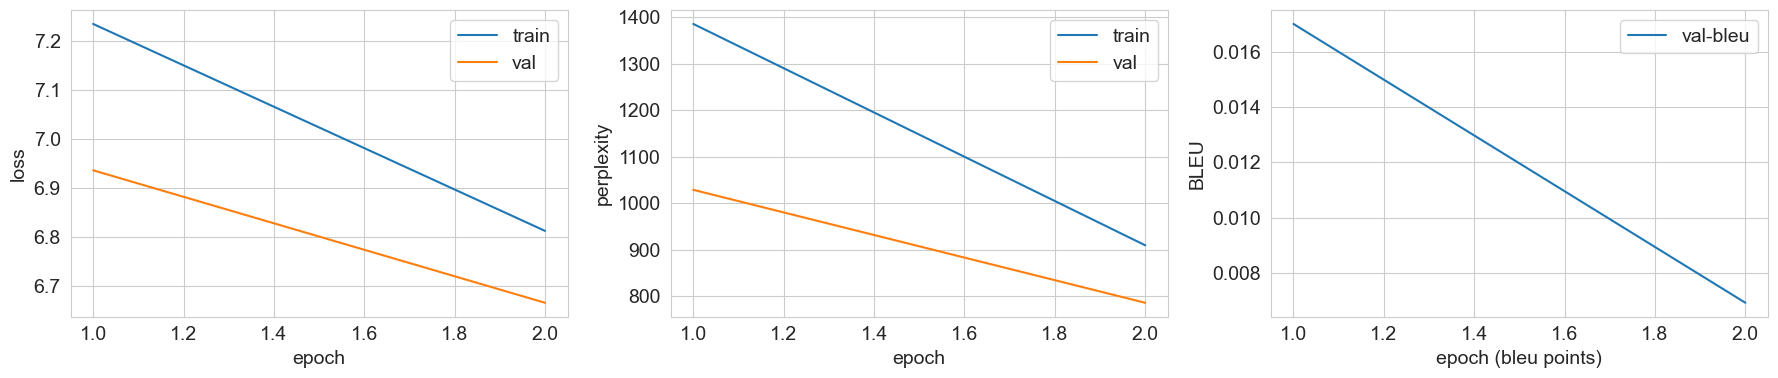

Train 3/50:   0%|          | 0/32 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [8]:
train_losses, val_losses, train_ppls, val_ppls, val_bleus = train(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    pad_idx=PAD,
    num_epochs=NUM_EPOCHS,
    val_dataset=val_ds,
    max_decoding_len=50,
    bleu_every=1,
    tmp_val_out="outputs/val_predictions.en",
    device=device,
    plot=True
)

In [ ]:
# BLEU на валидации

val_src = open("data/val.de-en.de", encoding="utf-8").read().splitlines()
val_ref = open("data/val.de-en.en", encoding="utf-8").read().splitlines()

VAL_OUTPUT_PATH = "outputs/val_predictions.en"

translate_file(
    model=model,
    dataset=val_ds,
    input_lines=val_src,
    device=device,
    output_path=VAL_OUTPUT_PATH,
    max_decoding_len=50
)

val_pred = open(VAL_OUTPUT_PATH, encoding="utf-8").read().splitlines()

bleu = sacrebleu.corpus_bleu(val_pred, [val_ref])
print("Validation BLEU:", bleu.score)

That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


Validation BLEU: 0.7061286390439332


In [ ]:
# примеры вывода

val_pred = open("outputs/val_predictions.en", encoding="utf-8").read().splitlines()
val_ref  = open("data/val.de-en.en", encoding="utf-8").read().splitlines()

preds_detok = [detokenize_english(s) for s in val_pred]
refs_detok = [detokenize_english(s) for s in val_ref]

bleu = sacrebleu.corpus_bleu(preds_detok, [refs_detok], tokenize='none')

print("Validation BLEU:", bleu.score)

print("counts: pred =", len(val_pred), "ref =", len(val_ref))

for i in range(10):
    print(f"\n=== Example {i} ===")
    print("PRED repr:", repr(preds_detok[i]))
    print("REF  repr:", repr(refs_detok[i]))

Validation BLEU: 0.10758339966410368
counts: pred = 986 ref = 986

=== Example 0 ===
PRED repr: "and i's,, i i i i, i's, a littlene, a littlene."
REF  repr: 'when i was 11, i remember waking up one morning to the sound of joy in my house.'

=== Example 1 ===
PRED repr: 'and,,,,,,,,,,,, they, the they, the the thes.'
REF  repr: 'my father was listening to bbc news on his small, gray radio.'

=== Example 2 ===
PRED repr: 'so,,,,,,, they, they, they, they, the theyss.'
REF  repr: 'there was a big smile on his face which was unusual then, because the news mostly depressed him.'

=== Example 3 ===
PRED repr: 'so,s,"""'
REF  repr: '"the taliban are gone!"my father shouted.'

=== Example 4 ===
PRED repr: "i's, it's,, it's,,,,,,,, you's."
REF  repr: "i didn't know what it meant, but i could see that my father was very, very happy."

=== Example 5 ===
PRED repr: "i's you's to be to bene,, i's."
REF  repr: '"you can go to a real school now,"he said.'

=== Example 6 ===
PRED repr: "so i i i i's."

In [ ]:
# прогноз для тестового набора

test_lines = open("data/test1.de-en.de", encoding="utf-8").read().splitlines()

OUTPUT_PATH = "outputs/test1.de-en.en"

translate_file(
    model=model,
    dataset=train_ds,
    input_lines=test_lines,
    device=device,
    output_path=OUTPUT_PATH,
    max_decoding_len=50
)

print(f"Test translations saved to {OUTPUT_PATH}")

Test translations saved to outputs/test1.de-en.en
